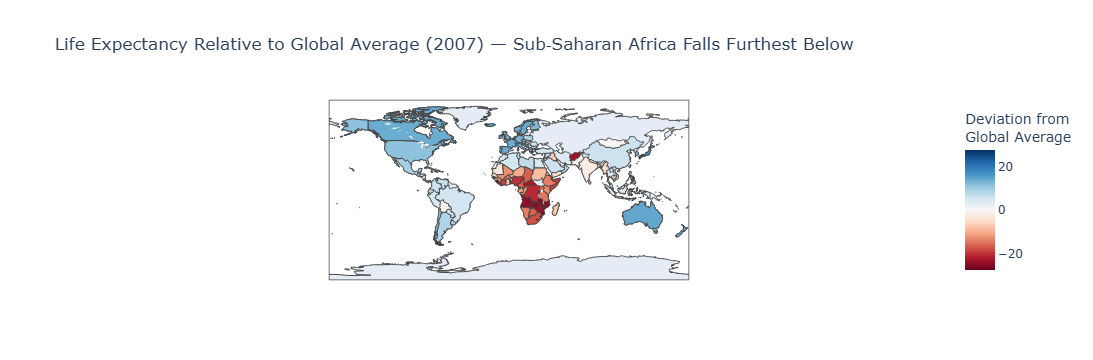

In [1]:
import plotly.express as px
import pandas as pd

# Load Gapminder dataset
gm = px.data.gapminder()

# Filter to 2007 only
gm_2007 = gm[gm['year'] == 2007].copy()

# Compute global average life expectancy
global_avg = gm_2007['lifeExp'].mean()

# Compute deviation from global mean
gm_2007['deviation'] = gm_2007['lifeExp'] - global_avg

# Build choropleth
fig = px.choropleth(
    gm_2007,
    locations="iso_alpha",
    color="deviation",
    hover_name="country",
    hover_data={
        "lifeExp": True,
        "deviation": True,
        "iso_alpha": False
    },
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0,
    title="Life Expectancy Relative to Global Average (2007) — Sub‑Saharan Africa Falls Furthest Below"
)

fig.update_layout(
    coloraxis_colorbar_title="Deviation from<br>Global Average"
)

fig.show()


{'name': 'Alabama', 'density': 94.65}


C:\Users\nages\AppData\Local\Temp\ipykernel_20388\503188677.py:22: DeprecationWarning:

*choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



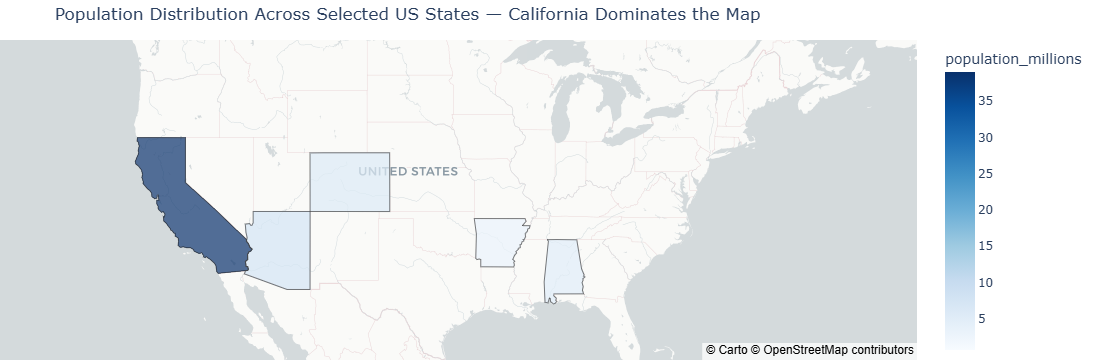

In [2]:
import json
import pandas as pd
import plotly.express as px

# Load GeoJSON for US states
import requests
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
my_geojson = requests.get(url).json()

# Inspect properties to find the correct key
print(my_geojson['features'][0]['properties'])
# → {'name': 'Alabama'}  → featureidkey = 'properties.name'

# Create a simple dataset: population by state (example values)
data = {
    "state": ["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado"],
    "population_millions": [5.0, 0.7, 7.4, 3.0, 39.0, 5.8]
}
df = pd.DataFrame(data)

# Build choropleth mapbox
fig = px.choropleth_mapbox(
    df,
    geojson=my_geojson,
    locations="state",
    featureidkey="properties.name",
    color="population_millions",
    color_continuous_scale="Blues",
    mapbox_style="carto-positron",
    zoom=3,
    center={"lat": 37.8, "lon": -96},
    opacity=0.7,
    hover_name="state",
    hover_data={"population_millions": True}
)

fig.update_layout(
    title="Population Distribution Across Selected US States — California Dominates the Map",
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()
